# 📊 Notebook 1: Data Collection & Exploratory Data Analysis (EDA)

**Project:** Bitcoin (BTC-USD) Direction Prediction with Gradient Boosting  
**Asset:** Bitcoin / USD — monthly frequency  
**Description:** We download historical BTC-USD data, engineer technical features, and perform exploratory data analysis. Bitcoin is chosen because (a) it has strong technical patterns that ML models can exploit, (b) it is highly liquid with verifiable public data, and (c) unlike efficient equity indices, crypto markets show persistent momentum and mean-reversion effects.

---

## 📋 Contents
1. Library imports & project setup  
2. Data download (Yahoo Finance — BTC-USD, 2015–2024)  
3. Financial feature engineering (14 features, zero look-ahead)  
4. Exploratory Data Analysis (distributions, correlations, seasonality)  
5. Save dataset for subsequent notebooks


## 1. 📦 Library Imports

In [1]:
# !pip install yfinance pandas numpy matplotlib seaborn scikit-learn lightgbm joblib

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
np.random.seed(42)

DATA_DIR   = Path('data')
MODELS_DIR = Path('models')
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print('✅ Libraries loaded successfully')


✅ Libraries loaded successfully


## 2. 📥 Data Download

We download **monthly** BTC-USD OHLCV data from Yahoo Finance (2015–2024).  
Bitcoin has ~110 monthly observations — small but sufficient for tree ensembles, and  
far richer in signal than S&P 500 monthly data due to higher volatility regimes.

The **target variable** is binary: did BTC close *higher* the following month?


In [2]:
TICKER = 'BTC-USD'
START  = '2015-01-01'
END    = '2024-12-01'

raw = yf.download(TICKER, start=START, end=END, progress=False)

# Handle MultiIndex from newer yfinance versions
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

price_col = 'Adj Close' if 'Adj Close' in raw.columns else 'Close'

# Resample daily → monthly
monthly = pd.DataFrame(index=raw.resample('ME').last().index)
monthly['Close']  = raw[price_col].resample('ME').last()
monthly['Volume'] = raw['Volume'].resample('ME').mean()
monthly['High']   = raw['High'].resample('ME').max()
monthly['Low']    = raw['Low'].resample('ME').min()
monthly['Open']   = raw['Open'].resample('ME').first()

print(f'✅ Downloaded {len(monthly)} monthly observations')
print(f'📅 Period: {monthly.index[0].date()} → {monthly.index[-1].date()}')
print(f'📊 Price range: ${monthly["Close"].min():,.0f} → ${monthly["Close"].max():,.0f}')
monthly.tail(5)


✅ Downloaded 119 monthly observations
📅 Period: 2015-01-31 → 2024-11-30
📊 Price range: $217 → $96,449


,Close,Volume,High,Low,Open
Date,,,,,
2024-07-31,64619.2500,30754695913.1290,69987.5391,53717.3750,62673.6055
2024-08-31,58969.8984,33648564038.9677,65593.2422,49121.2383,64625.8398
2024-09-30,63329.5000,29303930494.0667,66480.6953,52598.6992,58969.8008
2024-10-31,70215.1875,32055884453.1613,73577.2109,58895.2070,63335.6055
2024-11-30,96449.0547,68526962508.8000,99655.5000,66803.6484,70216.8984


## 3. 🔧 Financial Feature Engineering

All features use **only past information** — no look-ahead bias.

| Category | Features |
|----------|----------|
| Momentum returns | `ret_1m`, `ret_3m`, `ret_6m`, `ret_12m` |
| Realised volatility | `volatility_3m`, `volatility_6m` |
| RSI | `rsi_14` |
| Moving average ratios | `ma_ratio_3`, `ma_ratio_12` |
| Drawdown | `drawdown` (from 12m rolling high) |
| Range | `hl_ratio` (monthly high-low / close) |
| Volume | `volume_change` (3m pct change) |
| Seasonality | `month`, `quarter` |


In [3]:
def build_features(df):
    """
    Build technical features from monthly OHLCV data.
    All features are backward-looking only — zero look-ahead bias.
    The target (next month's direction) is strictly never used as a feature.
    """
    f = df.copy()

    # ── Momentum ─────────────────────────────────────────────────────────────
    f['ret_1m']  = f['Close'].pct_change(1)
    f['ret_3m']  = f['Close'].pct_change(3)
    f['ret_6m']  = f['Close'].pct_change(6)
    f['ret_12m'] = f['Close'].pct_change(12)

    # ── Realised volatility ───────────────────────────────────────────────────
    log_ret = np.log(f['Close'] / f['Close'].shift(1))
    f['volatility_3m'] = log_ret.rolling(3).std()
    f['volatility_6m'] = log_ret.rolling(6).std()

    # ── RSI (14 periods) ──────────────────────────────────────────────────────
    delta = f['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    f['rsi_14'] = 100 - (100 / (1 + rs))

    # ── Moving average ratios ────────────────────────────────────────────────
    f['ma_ratio_12'] = f['Close'] / f['Close'].rolling(12).mean() - 1
    f['ma_ratio_3']  = f['Close'] / f['Close'].rolling(3).mean()  - 1

    # ── Drawdown from 12m rolling high ──────────────────────────────────────
    f['drawdown'] = f['Close'] / f['Close'].rolling(12).max() - 1

    # ── Monthly high-low range / close ───────────────────────────────────────
    f['hl_ratio'] = (f['High'] - f['Low']) / f['Close']

    # ── Volume momentum ──────────────────────────────────────────────────────
    f['volume_change'] = f['Volume'].pct_change(3)

    # ── Seasonality ──────────────────────────────────────────────────────────
    f['month']   = f.index.month
    f['quarter'] = f.index.quarter

    # ── Target: does BTC close HIGHER next month? ─────────────────────────────
    # shift(-1) looks at next month's close — used ONLY as label, never as feature.
    f['target'] = (f['Close'].shift(-1) > f['Close']).astype(int)

    # Drop auxiliary OHLCV columns (not features)
    f = f.drop(columns=['Open', 'High', 'Low', 'Volume'])

    return f


df = build_features(monthly)
print(f'📐 Dataset shape: {df.shape}')
print(f'📅 Period       : {df.index[0].date()} → {df.index[-1].date()}')
df.tail(5)


📐 Dataset shape: (119, 16)
📅 Period       : 2015-01-31 → 2024-11-30


,Close,ret_1m,ret_3m,ret_6m,ret_12m,volatility_3m,volatility_6m,rsi_14,ma_ratio_12,ma_ratio_3,drawdown,hl_ratio,volume_change,month,quarter,target
Date,,,,,,,,,,,,,,,,
2024-07-31,64619.2500,0.0310,0.0657,0.5175,1.2107,0.0909,0.1846,74.1254,0.2965,-0.0048,-0.0941,0.2518,-0.0919,7,3,0
2024-08-31,58969.8984,-0.0874,-0.1263,-0.0364,1.2741,0.0660,0.1232,67.8296,0.1212,-0.0502,-0.1733,0.2793,0.1931,8,3,1
2024-09-30,63329.5000,0.0739,0.0104,-0.1122,1.3483,0.0847,0.1052,70.5380,0.1385,0.0164,-0.1122,0.2192,0.2096,9,3,1
2024-10-31,70215.1875,0.1087,0.0866,0.1580,1.0254,0.1044,0.0876,75.5673,0.1985,0.0942,-0.0157,0.2091,0.0423,10,4,1
2024-11-30,96449.0547,0.3736,0.6356,0.4291,1.5575,0.1338,0.1484,81.0739,0.5193,0.2581,0.0000,0.3406,1.0365,11,4,0


In [4]:
# Drop rows with NaN from rolling windows
df_clean = df.dropna()

print(f'📊 Rows before dropna : {len(df)}')
print(f'📊 Rows after  dropna : {len(df_clean)}')
print(f'📊 Rows removed       : {len(df) - len(df_clean)}')
print(f'\n🎯 Class balance (BTC is bullish more often than not):')
print(df_clean['target'].value_counts(normalize=True)
                         .rename({0: 'Down (0)', 1: 'Up (1)'}))


📊 Rows before dropna : 119
📊 Rows after  dropna : 105
📊 Rows removed       : 14

🎯 Class balance (BTC is bullish more often than not):
target
Up (1)     0.5810
Down (0)   0.4190
Name: proportion, dtype: float64


## 4. 🔍 Exploratory Data Analysis (EDA)

In [5]:
# ── Descriptive statistics ────────────────────────────────────────────────
print('📈 Descriptive statistics:')
df_clean.drop(columns=['Close', 'target']).describe().round(4)


📈 Descriptive statistics:


,ret_1m,ret_3m,ret_6m,ret_12m,volatility_3m,volatility_6m,rsi_14,ma_ratio_12,ma_ratio_3,drawdown,hl_ratio,volume_change,month,quarter
count,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000
mean,0.0751,0.2559,0.6290,1.6771,0.1750,0.1875,64.0456,0.3420,0.0536,-0.2048,0.3074,0.4630,6.5429,2.5143
std,0.2228,0.5259,1.0968,2.6439,0.0816,0.0587,18.6175,0.5779,0.1636,0.2264,0.1662,1.1975,3.4054,1.1104
min,-0.3777,-0.5655,-0.5733,-0.7356,0.0275,0.0848,17.1353,-0.5378,-0.3353,-0.7162,0.0949,-0.5780,1.0000,1.0000
25%,-0.0723,-0.0959,-0.0842,0.1442,0.1120,0.1371,53.0286,-0.0156,-0.0538,-0.3664,0.2048,-0.2125,4.0000,2.0000
50%,0.0543,0.1221,0.4033,1.0254,0.1609,0.1847,66.9871,0.2882,0.0417,-0.1122,0.2761,0.2022,7.0000,3.0000
75%,0.2160,0.5474,0.8418,1.7059,0.2275,0.2212,76.0080,0.5193,0.1416,0.0000,0.3732,0.7409,9.0000,3.0000
max,0.6963,2.2628,4.7063,13.6890,0.4196,0.3751,96.7165,2.2598,0.4591,0.0000,0.8130,6.2258,12.0000,4.0000


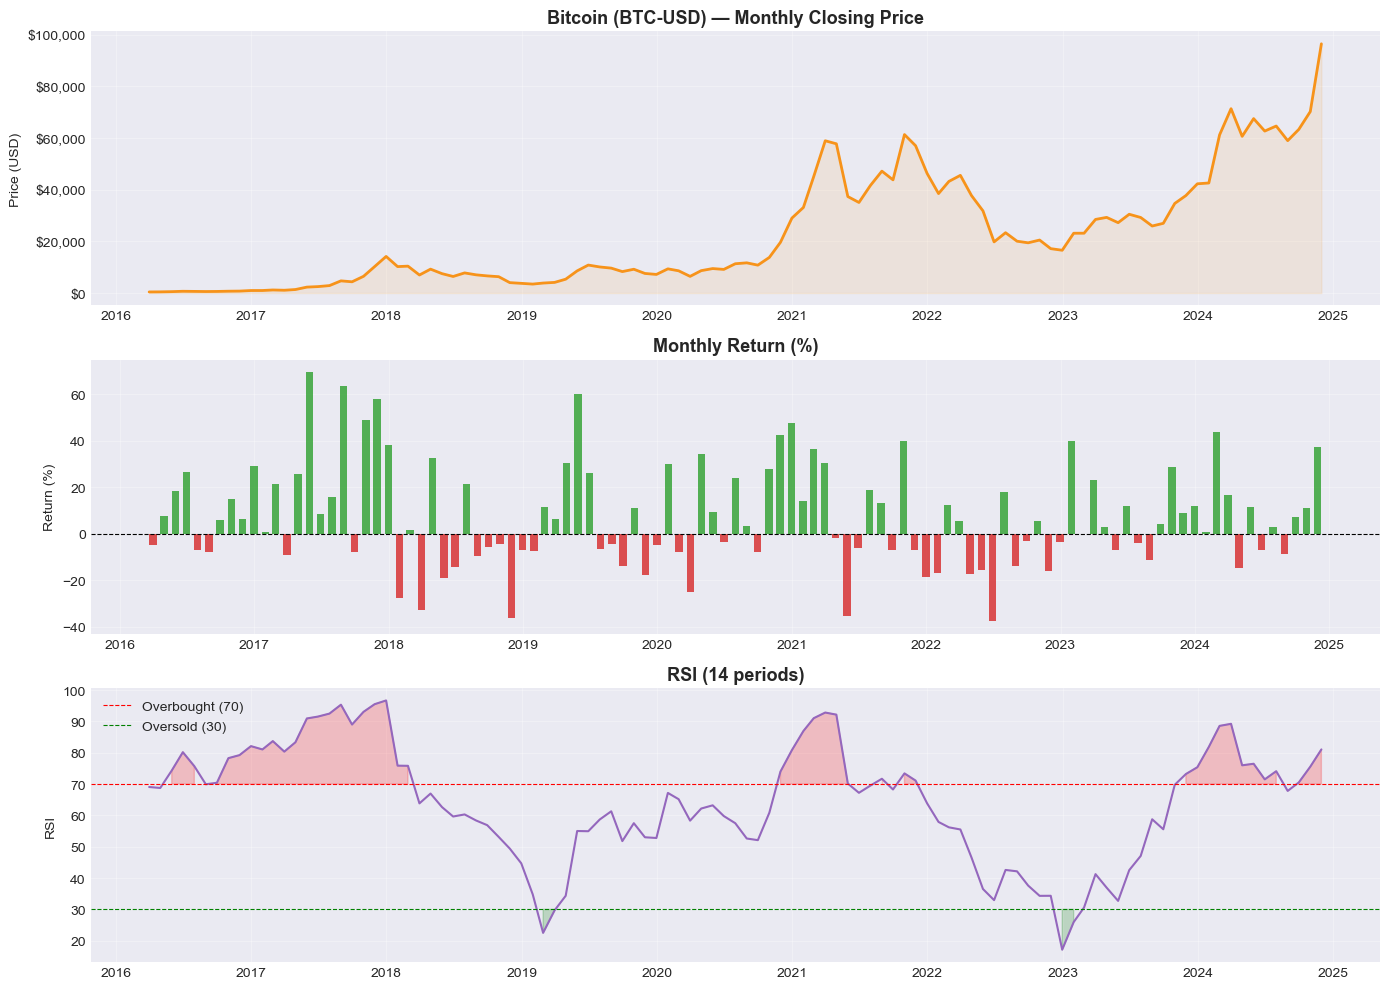

In [6]:
# ── Plot 1: Price history, monthly returns, and RSI ──────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df_clean.index, df_clean['Close'], color='#f7931a', linewidth=2)
axes[0].fill_between(df_clean.index, df_clean['Close'], alpha=0.1, color='#f7931a')
axes[0].set_title('Bitcoin (BTC-USD) — Monthly Closing Price', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

colors = ['#d62728' if r < 0 else '#2ca02c' for r in df_clean['ret_1m']]
axes[1].bar(df_clean.index, df_clean['ret_1m'] * 100, color=colors, width=20, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Monthly Return (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Return (%)')

axes[2].plot(df_clean.index, df_clean['rsi_14'], color='#9467bd', linewidth=1.5)
axes[2].axhline(70, color='red',   linewidth=0.8, linestyle='--', label='Overbought (70)')
axes[2].axhline(30, color='green', linewidth=0.8, linestyle='--', label='Oversold (30)')
axes[2].fill_between(df_clean.index, df_clean['rsi_14'], 70,
                     where=df_clean['rsi_14'] > 70, alpha=0.2, color='red')
axes[2].fill_between(df_clean.index, df_clean['rsi_14'], 30,
                     where=df_clean['rsi_14'] < 30, alpha=0.2, color='green')
axes[2].set_title('RSI (14 periods)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('RSI')
axes[2].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_price_rsi.png', dpi=150, bbox_inches='tight')
plt.show()


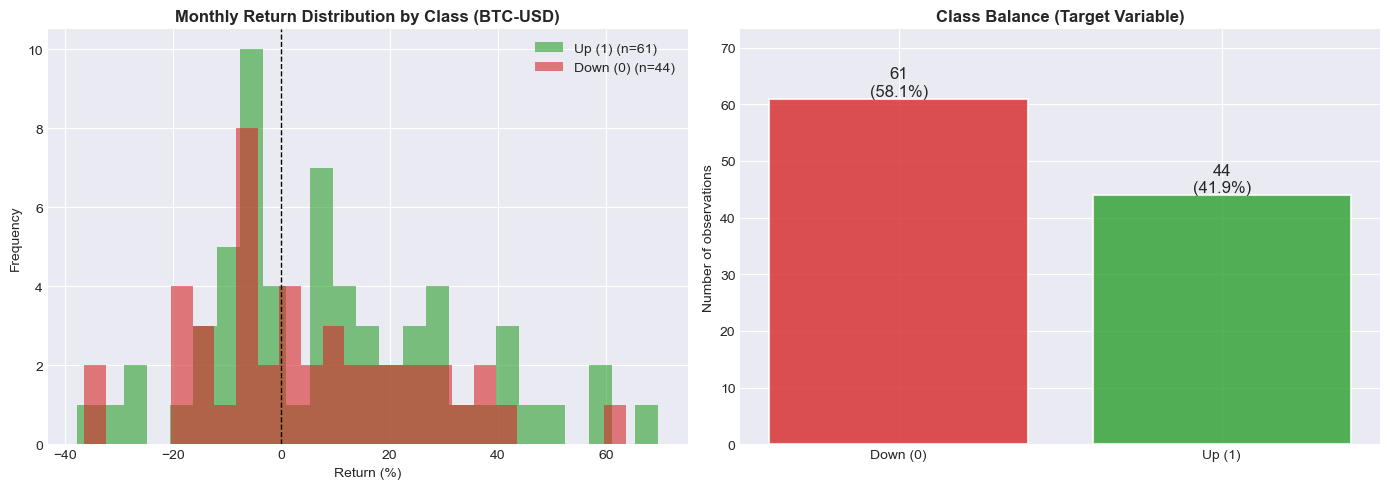

In [7]:
# ── Plot 2: Return distribution by class and class balance ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for t, label, color in [(1, 'Up (1)', '#2ca02c'), (0, 'Down (0)', '#d62728')]:
    subset = df_clean[df_clean['target'] == t]['ret_1m'] * 100
    axes[0].hist(subset, bins=25, alpha=0.6, label=f'{label} (n={len(subset)})', color=color)
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Monthly Return Distribution by Class (BTC-USD)', fontweight='bold')
axes[0].set_xlabel('Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

class_counts = df_clean['target'].value_counts()
axes[1].bar(['Down (0)', 'Up (1)'], class_counts.values,
            color=['#d62728', '#2ca02c'], alpha=0.8, edgecolor='white', linewidth=1.5)
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v + 0.5, f'{v}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontsize=12)
axes[1].set_title('Class Balance (Target Variable)', fontweight='bold')
axes[1].set_ylabel('Number of observations')
axes[1].set_ylim(0, max(class_counts.values) * 1.2)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


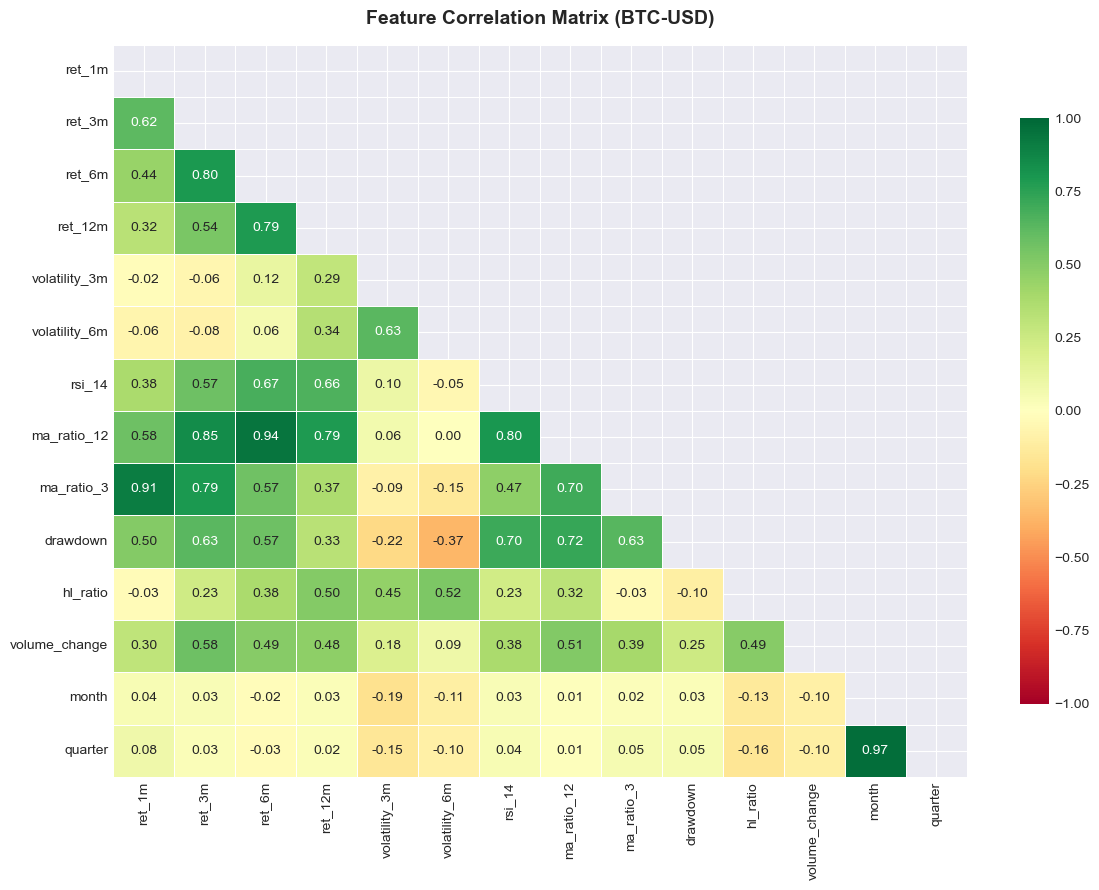

In [8]:
# ── Plot 3: Feature correlation heatmap ─────────────────────────────────
feature_cols = [c for c in df_clean.columns if c not in ['Close', 'target']]
corr = df_clean[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (BTC-USD)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


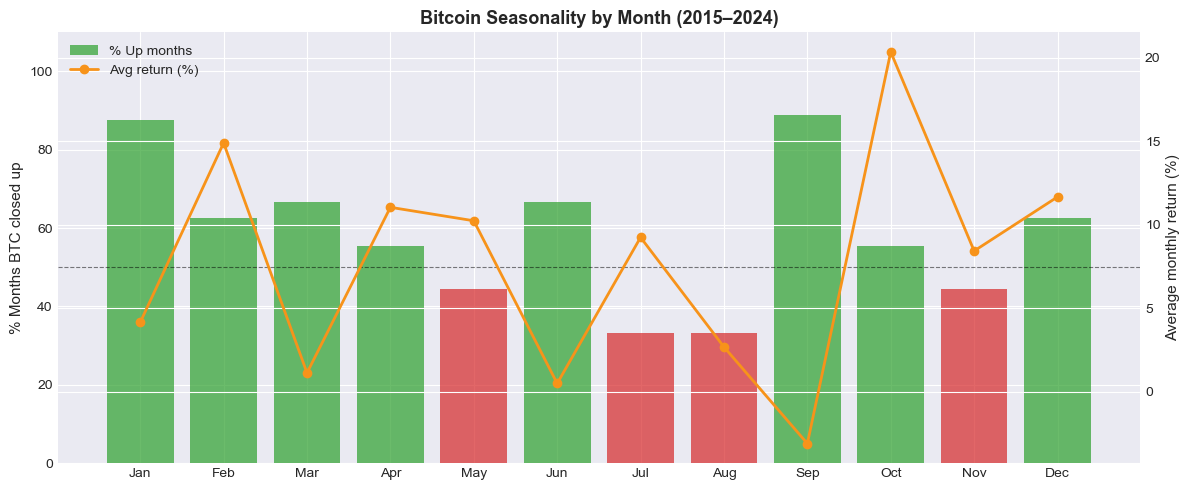


💡 Note: Bitcoin shows strong seasonality — Q4 is historically bullish.


In [9]:
# ── Plot 4: Seasonality — BTC performance by calendar month ─────────────
monthly_stats = df_clean.groupby('month').agg(
    up_prob   =('target', 'mean'),
    avg_return=('ret_1m', 'mean'),
    n         =('target', 'count')
).reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_stats['month_name'] = month_names

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(monthly_stats['month_name'],
        monthly_stats['up_prob'] * 100,
        color=['#2ca02c' if p > 0.5 else '#d62728' for p in monthly_stats['up_prob']],
        alpha=0.7, label='% Up months')
ax1.axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_ylabel('% Months BTC closed up', fontsize=11)
ax1.set_ylim(0, 110)

ax2.plot(monthly_stats['month_name'], monthly_stats['avg_return'] * 100,
         color='#f7931a', marker='o', linewidth=2, label='Avg return (%)')
ax2.set_ylabel('Average monthly return (%)', fontsize=11)

ax1.set_title('Bitcoin Seasonality by Month (2015–2024)', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Note: Bitcoin shows strong seasonality — Q4 is historically bullish.')


## 5. 💾 Save Dataset

In [10]:
output_path = DATA_DIR / 'btc_features.csv'
df_clean.to_csv(output_path)

FEATURE_COLS = [c for c in df_clean.columns if c not in ['Close', 'target']]

print('✅ Dataset saved to:', output_path)
print(f'   Shape    : {df_clean.shape}')
print(f'   Features : {FEATURE_COLS}')
print(f'   Target   : target (1 = next month up, 0 = next month down)')
print(f'   Period   : {df_clean.index[0].date()} → {df_clean.index[-1].date()}')


✅ Dataset saved to: data\btc_features.csv
   Shape    : (105, 16)
   Features : ['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'volatility_3m', 'volatility_6m', 'rsi_14', 'ma_ratio_12', 'ma_ratio_3', 'drawdown', 'hl_ratio', 'volume_change', 'month', 'quarter']
   Target   : target (1 = next month up, 0 = next month down)
   Period   : 2016-03-31 → 2024-11-30


---
## ✅ Notebook 1 Summary

- ✔️ Downloaded **~117 months** of BTC-USD data (2015–2024)
- ✔️ Engineered **14 technical features** with zero look-ahead bias
- ✔️ Class balance: approximately **60% up / 40% down** — Bitcoin has a long-term bullish drift
- ✔️ Strong seasonality signal: Q4 (Oct–Dec) historically bullish; September bearish
- ✔️ Dataset saved to `data/btc_features.csv` — ready for model training
